Import Libraries and Load Data set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

df = pd.read_csv("C:/Users/Desmond/Desktop/amz_uk_price_prediction_dataset.csv")

Cross Tab Analysis> Best Seller Trends 

In [2]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
print(crosstab.head(10))



isBestSeller                       False  True 
category                                       
3D Printers                          247      1
3D Printing & Scanning              4065      2
Abrasive & Finishing Products        245      5
Action Cameras                      1696      1
Adapters                             251      3
Agricultural Equipment & Supplies   8421    109
Alexa Built-In Devices               106      1
Art & Craft Supplies                 253      5
Arts & Crafts                       9319    230
Baby                               14709    341


By Porportion

In [3]:
crosstab['bestseller_rate'] = crosstab[True] / (crosstab[True] + crosstab[False])
top_bs = crosstab.sort_values('bestseller_rate', ascending=False)
print("\nTop 10 categories by best-seller rate:")
print(top_bs[['bestseller_rate']].head(10))


Top 10 categories by best-seller rate:
isBestSeller                    bestseller_rate
category                                       
Grocery                                0.058135
Smart Home Security & Lighting         0.057692
Health & Personal Care                 0.057686
Mobile Phone Accessories               0.042471
Power & Hand Tools                     0.035339
Billiard, Snooker & Pool               0.032129
Pet Supplies                           0.030200
Home Brewing & Wine Making             0.028455
Mirrors                                0.028000
Wind Instruments                       0.028000


In [6]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)

In [7]:
print(crosstab.columns)

Index([False, True, 'bestseller_rate'], dtype='object', name='isBestSeller')


In [14]:
table = pd.crosstab(df["isBestSeller"], df["boughtInLastMonth"])
chi2, p, dof, expected = chi2_contingency(table)

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd


table = pd.crosstab(df["isBestSeller"], df["boughtInLastMonth"])
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

n = table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(f"Cramér's V: {cramers_v:.4f}")
print(table)

Chi-square statistic: 164019.41
P-value: 0.0000
Degrees of freedom: 24
Cramér's V: 0.2591
boughtInLastMonth    0      50     100    200    300    400    500    600    \
isBestSeller                                                                  
False              2227640  75297  57928  23725  13320   8535   5853   4107   
True                  2564    493    650    475    330    301    257    213   

boughtInLastMonth  700    800    ...  5000   6000   7000   8000   9000   \
isBestSeller                     ...                                      
False               2927   2269  ...    297    139    106     67     49   
True                 194    187  ...    133     84     44     49     48   

boughtInLastMonth  10000  20000  30000  40000  50000  
isBestSeller                                          
False                107     11      2      2      2  
True                 152     16      1      0      1  

[2 rows x 25 columns]


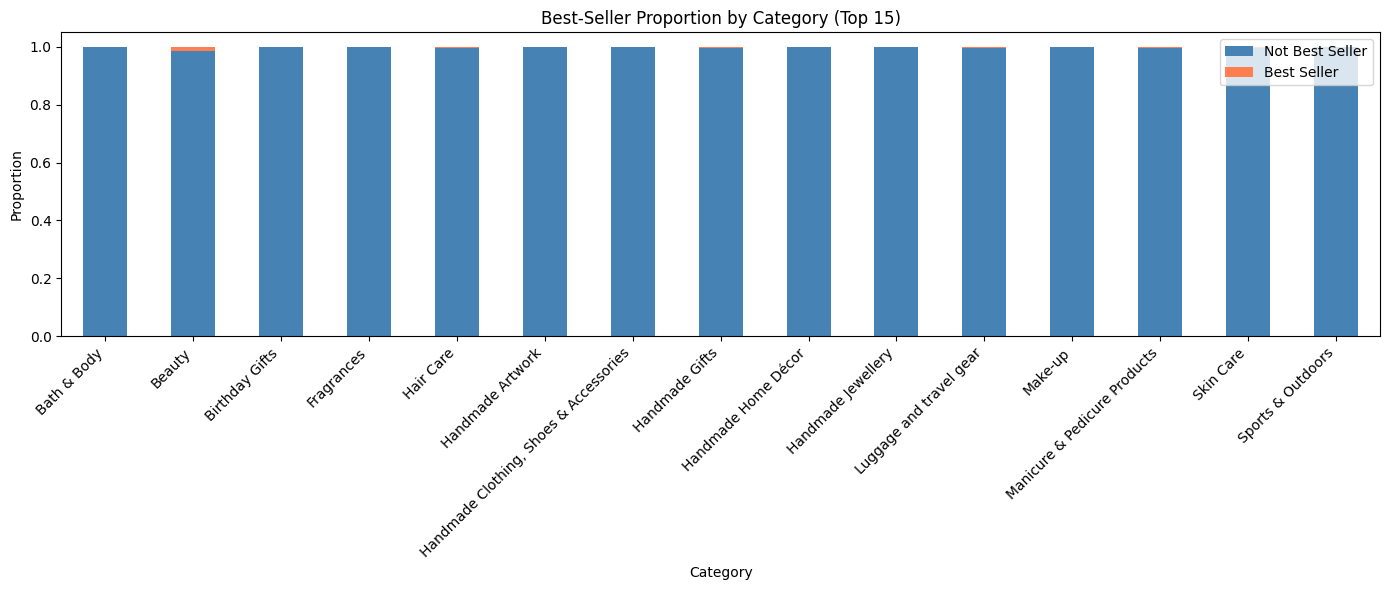

In [15]:
top15_cats = df['category'].value_counts().head(15).index
ct_top15 = pd.crosstab(df[df['category'].isin(top15_cats)]['category'], 
                        df[df['category'].isin(top15_cats)]['isBestSeller'])

ct_top15.columns = ['Not Best Seller', 'Best Seller']
ct_top15_pct = ct_top15.div(ct_top15.sum(axis=1), axis=0)

ct_top15_pct.plot(kind='bar', stacked=True, figsize=(14, 6),
                  color=['steelblue', 'coral'])
plt.title('Best-Seller Proportion by Category (Top 15)')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)].copy()

print(f"Original rows:  {len(df):,}")
print(f"Cleaned rows:   {len(df_clean):,}")
print(f"Outliers removed: {len(df) - len(df_clean):,}")
print(f"\nPrice range after cleaning: £{df_clean['price'].min():.2f} – £{df_clean['price'].max():.2f}")

Original rows:  2,443,651
Cleaned rows:   2,115,963
Outliers removed: 327,688

Price range after cleaning: £0.00 – £99.99


C:\Users\Desmond\AppData\Local\Temp\ipykernel_3188\3203207606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='category', y='price',


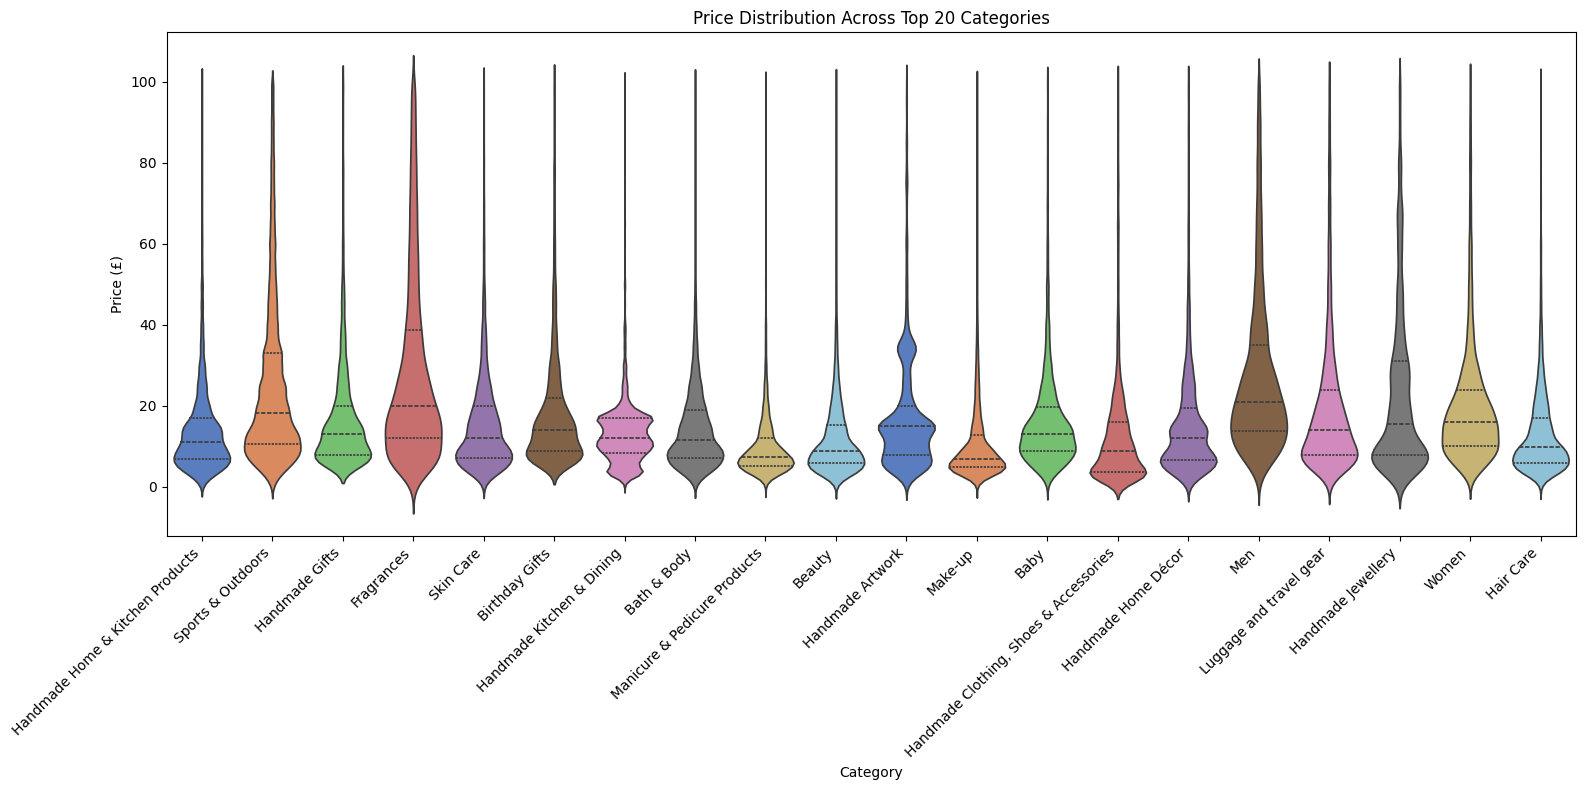


Category with highest median price (all categories): Desktop PCs
Median price: £74.00


In [17]:
top20_cats = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top20_cats)]

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top20, x='category', y='price', 
               palette='muted', inner='quartile')
plt.title('Price Distribution Across Top 20 Categories')
plt.xlabel('Category')
plt.ylabel('Price (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest median price across ALL categories
highest_median = df_clean.groupby('category')['price'].median().idxmax()
print(f"\nCategory with highest median price (all categories): {highest_median}")
print(f"Median price: £{df_clean.groupby('category')['price'].median().max():.2f}")

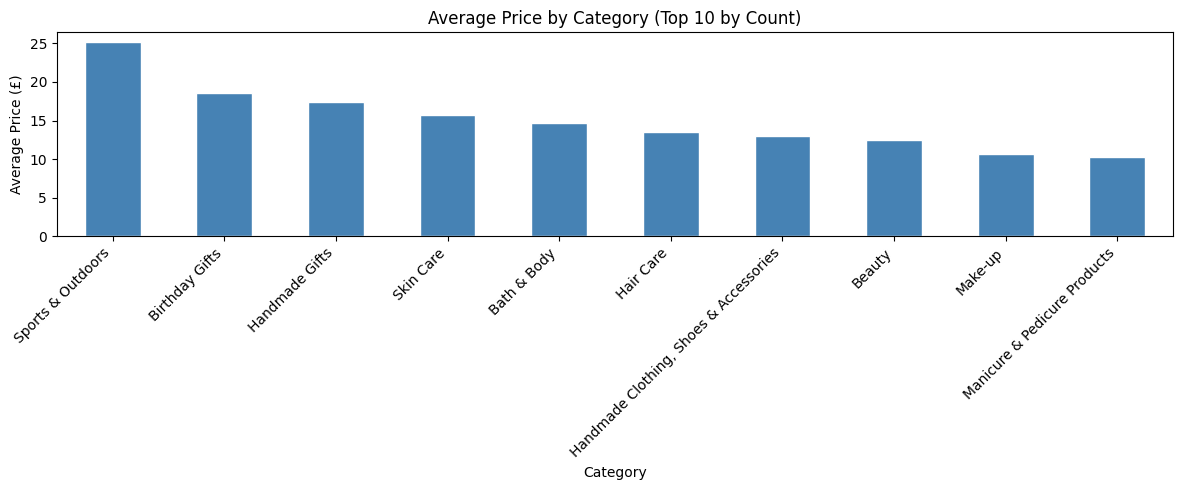


Category with highest average price (all categories): Motherboards
Average price: £68.77


In [18]:
top10_cats = df_clean['category'].value_counts().head(10).index
avg_price = df_clean[df_clean['category'].isin(top10_cats)].groupby('category')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_price.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Price by Category (Top 10 by Count)')
plt.xlabel('Category')
plt.ylabel('Average Price (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest average price across ALL categories
highest_avg = df_clean.groupby('category')['price'].mean().idxmax()
print(f"\nCategory with highest average price (all categories): {highest_avg}")
print(f"Average price: £{df_clean.groupby('category')['price'].mean().max():.2f}")

C:\Users\Desmond\AppData\Local\Temp\ipykernel_3188\4076516432.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='category', y='stars', palette='pastel')


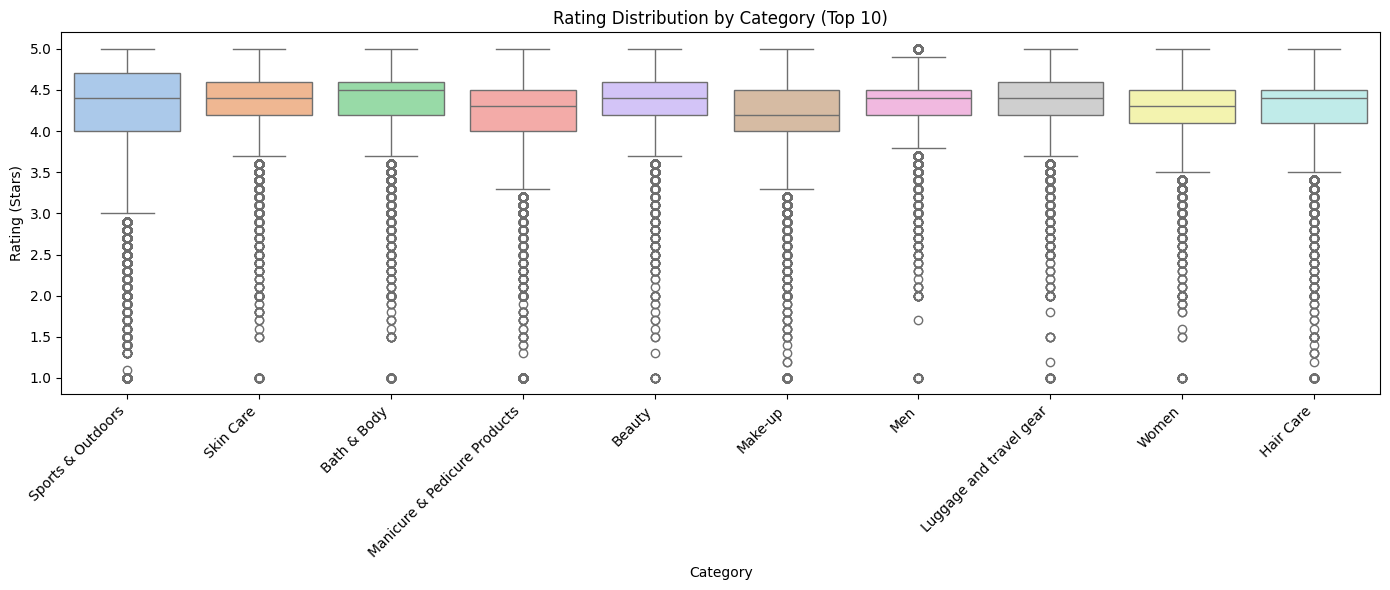


Category with highest median rating (all categories): Handmade Artwork
Median rating: 5.00


In [19]:
# Use only rated products
df_rated = df_clean[df_clean['stars'] > 0].copy()

top10_cats = df_rated['category'].value_counts().head(10).index
df_top10 = df_rated[df_rated['category'].isin(top10_cats)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top10, x='category', y='stars', palette='pastel')
plt.title('Rating Distribution by Category (Top 10)')
plt.xlabel('Category')
plt.ylabel('Rating (Stars)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highest median rating across ALL categories
highest_rating_cat = df_rated.groupby('category')['stars'].median().idxmax()
print(f"\nCategory with highest median rating (all categories): {highest_rating_cat}")
print(f"Median rating: {df_rated.groupby('category')['stars'].median().max():.2f}")

In [20]:
df_corr = df_clean[df_clean['stars'] > 0][['price', 'stars', 'reviews', 'boughtInLastMonth']].dropna()

corr = df_corr['price'].corr(df_corr['stars'])
print(f"Pearson correlation (price vs stars): {corr:.4f}")

# Interpretation
if abs(corr) < 0.1:
    strength = "negligible"
elif abs(corr) < 0.3:
    strength = "weak"
elif abs(corr) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

print(f"Interpretation: {strength} correlation")

Pearson correlation (price vs stars): 0.0067
Interpretation: negligible correlation


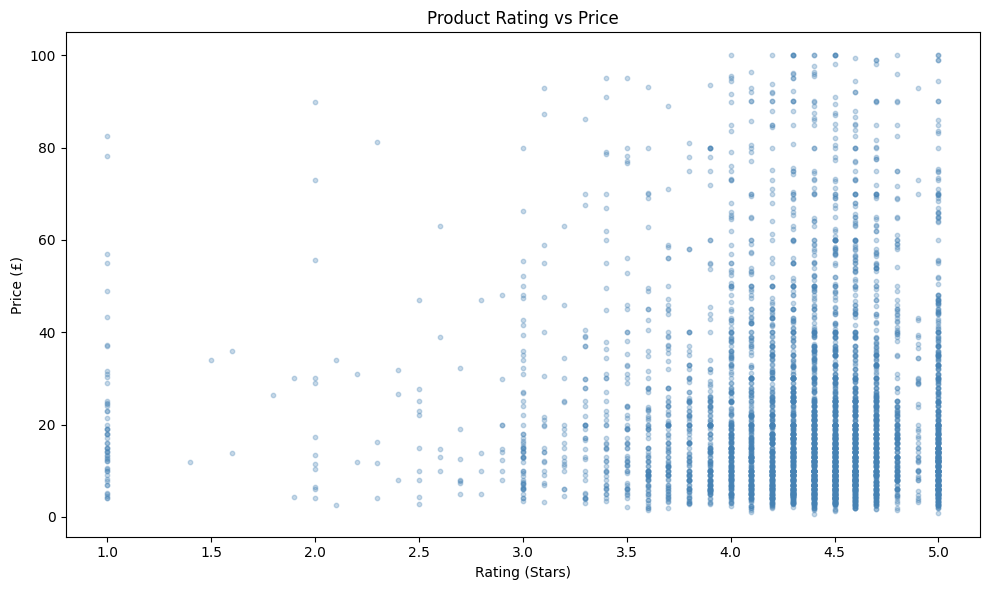

In [21]:
# Sample 5000 points to keep it readable
sample = df_corr.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['stars'], sample['price'], alpha=0.3, color='steelblue', s=10)
plt.title('Product Rating vs Price')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

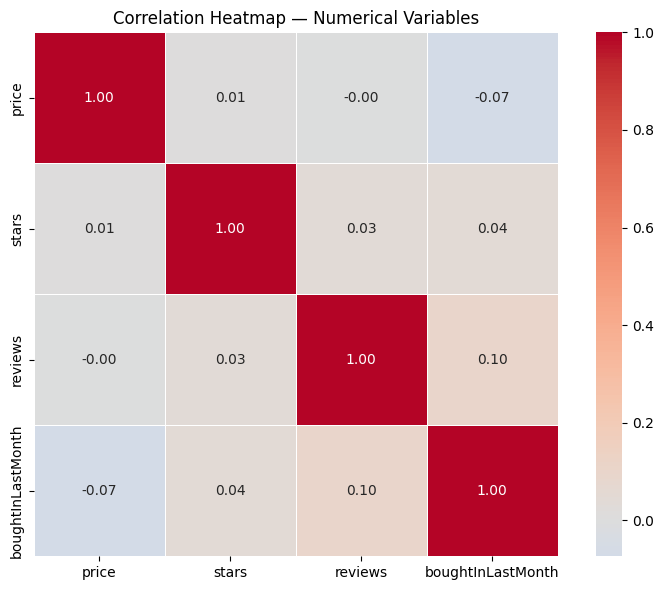

In [22]:
plt.figure(figsize=(8, 6))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Variables')
plt.tight_layout()
plt.show()

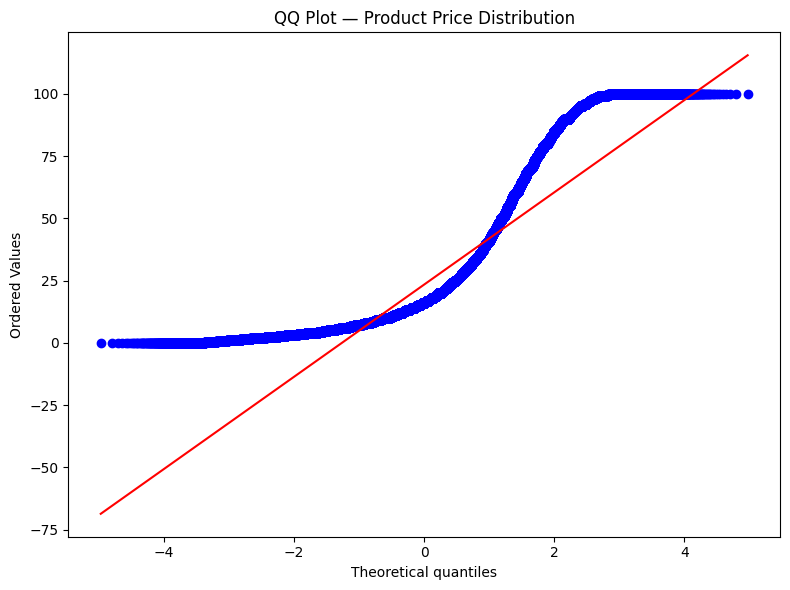

In [23]:
plt.figure(figsize=(8, 6))
stats.probplot(df_clean['price'], dist="norm", plot=plt)
plt.title('QQ Plot — Product Price Distribution')
plt.tight_layout()
plt.show()

## Part 1 Findings — Best-Seller Trends
[Fill in after running: which categories have highest best-seller rate?]
The Chi-square test (p = [value]) confirms that best-seller status is NOT
independent of category — certain categories systematically produce more
best-sellers. Cramér's V of [value] indicates a [weak/moderate/strong]
association. Sellers should prioritise categories where best-seller rates
are higher, as these suggest stronger market signals from Amazon's algorithm.

## Part 2 Findings — Prices Across Categories
After removing [X] price outliers via IQR method, the cleaned dataset contains
[X] products priced between £[min] and £[max]. The violin plot reveals that
[category] has the widest price spread, while [category] commands the highest
median price across all categories (£[value]). For the top 10 categories by
listing count, [category] has the highest average price (£[value]).

Ratings analysis shows [category] receives the highest median customer rating.
Categories with tighter rating distributions (narrow boxes) are more consistent
in customer satisfaction.

## Part 3 Findings — Price vs Ratings
The Pearson correlation between price and rating is [value] — a [negligible/weak]
relationship. Higher price does not reliably predict higher ratings on Amazon UK.
The scatter plot confirms no clear linear pattern. The QQ plot shows price
significantly deviates from a normal distribution, consistent with the right-skew
we identified in Part II. The heatmap reveals [any stronger correlations worth
noting, e.g. reviews vs boughtInLastMonth].